# Silicon Nep89 Calorine

### Anharmonic Lattice Dynamics (ALD) for $\ce{Si}$ with [NEP](https://pubs.aip.org/aip/jap/article/135/16/161101/3284756)

#### Import Necessary Packages

In [1]:
from ase.io import read
from ase.visualize.plot import plot_atoms
import pandas as pd
from pylab import *
import warnings
warnings.filterwarnings("ignore")

#### Custom Define Functions

In [2]:
def cumulative_cond_cal(observables, kappa_tensor, prefactor=1/3):

    """Compute cumulative conductivity based on either frequency or mean-free path

       input:
       observables: (ndarray) either phonon frequency or mean-free path
       cond_tensor: (ndarray) conductivity tensor
       prefactor: (float) prefactor to average kappa tensor, 1/3 for bulk material

       ouput:
       observeables: (ndarray) sorted phonon frequency or mean-free path
       kappa_cond (ndarray) cumulative conductivity

    """

    # Sum over kappa by directions
    kappa = np.einsum('maa->m', prefactor * kappa_tensor)

    # Sort observables
    observables_argsort_indices = np.argsort(observables)
    cumulative_kappa = np.cumsum(kappa[observables_argsort_indices])
    return observables[observables_argsort_indices], cumulative_kappa



def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

#### Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

#### Illustrate Crystal Structure and Elastic Constants
- DFT reference for the elastic modulus is adopted from: https://next-gen.materialsproject.org/materials/mp-149

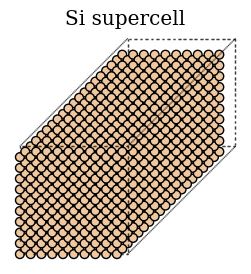



  Properties  Predictions (GPa)  DFT references (GPa)
         C11              158.8                   153
         C12               62.5                    57
         C44               63.9                    74
Bulk Modulus               94.6                    89


In [4]:
# Denote data path
data_folder = "kaldo_runs/"

# Extract supercell structure for later display
atoms = read(data_folder  + 'fd_NEP/replicated_atoms.xyz')

# Retrieve elastic constants and compute bulk modulus
# note that the equation works for cubic system only
Cijs = np.load(data_folder + 'Cij.npy')
C11 = Cijs[0, 0, 0, 0]
C12 = Cijs[0, 0, 1, 1]
C44 = Cijs[1, 2, 1, 2]
Bulk_modulus = (C11 + 2 * C12)/3

# Display supercell and bulk modulus side by side
figure(figsize=(4, 3))
set_fig_properties([gca()])
plot_atoms(atoms)
gca().axis('off')
gca().set_title('Si supercell')
show()

print('\n')

# Prepare data for pandas
df = pd.DataFrame({
    "Properties": ["C11", "C12", "C44", "Bulk Modulus"],
    "Predictions (GPa)": [C11, C12, C44, Bulk_modulus],
    "DFT references (GPa)": [153, 57, 74 ,89]
})

# Format the floats to one decimal place and print
pd.set_option('display.float_format', '{:.1f}'.format)
print(df.to_string(index=False))

#### Plot Phonon Spectra (Dispersion) and Density of State (DOS)

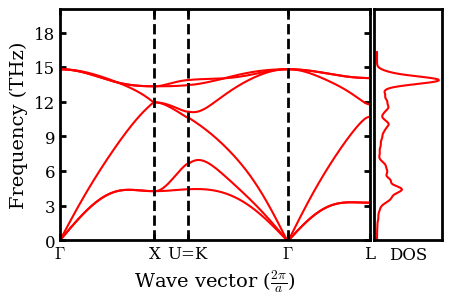

In [5]:
# Derive symbols for high symmetry directions in Brillouin zone
dispersion = np.loadtxt(data_folder  + 'plots/15_15_15/dispersion')
point_names = np.loadtxt(data_folder  + 'plots/15_15_15/point_names', dtype=str)

point_names_list = []
for point_name in point_names:
    if point_name == 'G':
        point_name = r'$\Gamma$'
    elif point_name == 'U':
        point_name = 'U=K'
    point_names_list.append(point_name)

# Load in the "tick-mark" values for these symbols
q = np.loadtxt(data_folder  + 'plots/15_15_15/q')
Q = np.loadtxt(data_folder  + 'plots/15_15_15/Q_val')

# Load in grid and dos individually
dos_Si= np.load(data_folder + 'plots/15_15_15/dos.npy')

# Plot dispersion
fig = figure(figsize=(4,3))
set_fig_properties([gca()])
plot(q[0], dispersion[0, 0], 'r-', ms=1)
plot(q, dispersion, 'r-', ms=1)
for i in range(1, 4):
    axvline(x=Q[i], ymin=0, ymax=2, ls='--',  lw=2, c="k")
ylabel('Frequency (THz)', fontsize=14)
xlabel(r'Wave vector ($\frac{2\pi}{a}$)', fontsize=14)
gca().set_yticks(np.arange(0, 24, 3))
xticks(Q, point_names_list)
ylim([0, 20])
xlim([Q[0], Q[4]])
dosax = fig.add_axes([0.91, .11, .17, .77])
set_fig_properties([gca()])

# Plot per projection
for d in np.expand_dims(dos_Si[1],0):
    dosax.plot(d, dos_Si[0],c='r')
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS")
ylim([0, 20])
show()

#### Plot Heat Capacity, Group Velocities and Phase Space

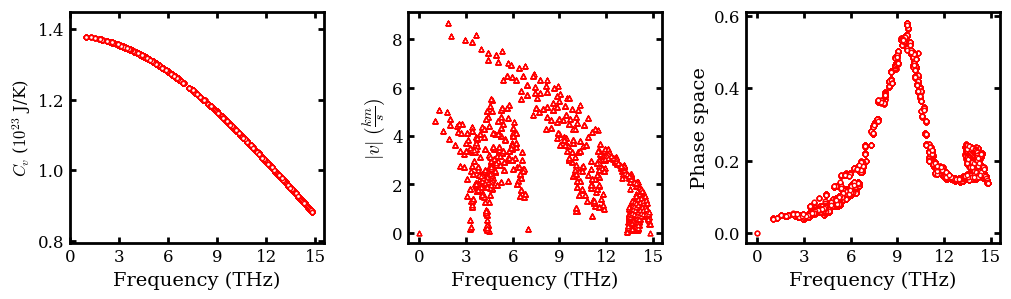

In [6]:
# Load in group velocity, heat_capacity (cv) and frequency data
frequency =  np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/frequency.npy',
    allow_pickle=True)

cv =  np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/300/quantum/heat_capacity.npy',
    allow_pickle=True)


group_velocity = np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/velocity.npy')

phase_space = np.load(data_folder +
 'ALD_Si_NEP/15_15_15/300/quantum/_ps_and_gamma.npy',
                      allow_pickle=True)[:,0]

# Compute norm of group velocity
# Convert the unit from angstrom / picosecond to kilometer/ second
group_velcotiy_norm = np.linalg.norm(
    group_velocity.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C')[3:], 1e23*cv.flatten(order='C')[3:], 
        facecolor='w', edgecolor='r', s=10, marker='8')
ylabel (r"$C_{v}$ ($10^{23}$ J/K)")
xlabel('Frequency (THz)', fontsize=14)
gca().set_xticks(np.arange(0, 18, 3))
ylim(0.9*1e23*cv.flatten(order='C')[3:].min(), 1.05*1e23*cv.flatten(order='C')[3:].max())

subplot(1 ,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        group_velcotiy_norm, facecolor='w', edgecolor='r', s=10, marker='^')
xlabel('Frequency (THz)', fontsize=14)
ylabel(r'$|v| \ (\frac{km}{s})$', fontsize=14)
gca().set_xticks(np.arange(0, 18, 3))

subplot(1 ,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        phase_space, facecolor='w', edgecolor='r', s=10, marker='o')
gca().set_xticks(np.arange(0, 18, 3))
xlabel('Frequency (THz)', fontsize=14)
ylabel('Phase space', fontsize=14)
subplots_adjust(wspace=0.33)
show()

#### Plot Phonon Lifetime ($\tau$), Scattering Rate ($\Gamma$) $\&$ MFP ($\lambda$)
- Note that $\Gamma$ and $\tau$ are computed only with the relaxation time approximation (RTA).

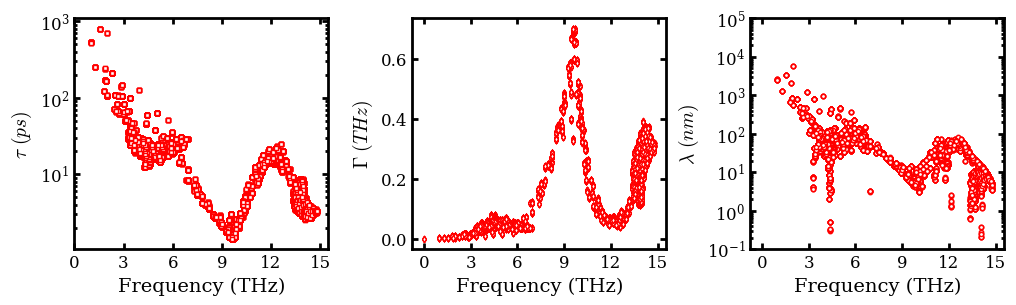

In [7]:
# Load in scattering rate
scattering_rate = np.load(
    data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/bandwidth.npy', allow_pickle=True)

# Derive lifetime, which is inverse of scattering rate
life_time = scattering_rate ** (-1)

# Denote lists to intake mean free path in each direction
mean_free_path = []
for i in range(3):
    mean_free_path.append(np.loadtxt(
    data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/inverse/mean_free_path_' +
    str(i) + '.dat'))

# Convert list to numpy array and compute norm for mean free path
# Convert the unit from angstrom  to nanometer
mean_free_path = np.array(mean_free_path).T
mean_free_path_norm = np.linalg.norm(
    mean_free_path.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        life_time, facecolor='w', edgecolor='r', s=10, marker='s')
gca().set_xticks(np.arange(0, 18, 3))
yscale('log')
ylabel(r'$\tau \ (ps)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        scattering_rate, facecolor='w', edgecolor='r', s=10, marker='d')
gca().set_xticks(np.arange(0, 18, 3))
ylabel(r'$\Gamma \ (THz)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        mean_free_path_norm, facecolor='w', edgecolor='r', s=10, marker='8')
gca().set_xticks(np.arange(0, 18, 3))
ylabel(r'$\lambda \ (nm)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
yscale('log')
ylim([1e-1, 1e5])
subplots_adjust(wspace=0.33)
show()


#### Plot per mode and cumulative $\kappa$

Bulk thermal conductivity: 137.1 W m^-1 K^-1

kappa matrix: 
[[1.37040119e+02 3.11632372e-02 3.46691949e-02]
 [3.08743512e-02 1.37288063e+02 3.10237043e-02]
 [3.46905807e-02 3.13405911e-02 1.37041830e+02]]


Bulk thermal conductivity with isotopic scattering: 124.5 W m^-1 K^-1

kappa matrix with isotopic scattering: 
[[1.24406786e+02 7.46386990e-02 7.90297496e-02]
 [7.43169047e-02 1.24642697e+02 7.44400437e-02]
 [7.90447810e-02 7.47888116e-02 1.24408462e+02]]




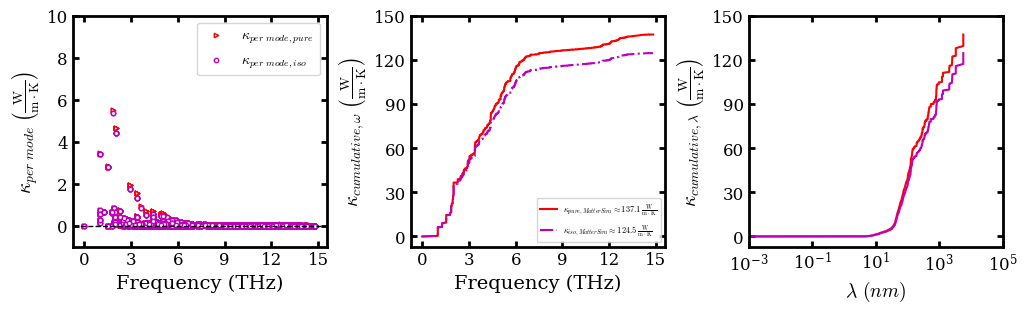

In [8]:
# Denote zeros to intake kappa tensor
kappa_tensor = np.zeros([mean_free_path.shape[0], 3, 3])
kappa_tensor_iso = np.zeros([mean_free_path.shape[0], 3, 3])

for i in range(3):
    for j in range(3):
        kappa_tensor[:, i, j] = np.loadtxt(data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/inverse/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
        kappa_tensor_iso[:, i, j] = np.loadtxt(data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/isotopes/inverse/conductivity_' +
    str(i) + '_' + str(j) + '.dat')

# Sum over the 0th dimension to recover 3-by-3 kappa matrix
kappa_matrix = kappa_tensor.sum(axis=0)
print("Bulk thermal conductivity: %.1f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix)))
print("kappa matrix: ")
print(kappa_matrix)
print('\n')

kappa_matrix_iso = kappa_tensor_iso.sum(axis=0)
print("Bulk thermal conductivity with isotopic scattering: %.1f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_iso)))
print("kappa matrix with isotopic scattering: ")
print(kappa_matrix_iso)
print('\n')

# Compute kappa in per mode and cumulative representations
kappa_per_mode = kappa_tensor.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor)
lambda_sorted, kappa_cum_wrt_lambda = cumulative_cond_cal(
    mean_free_path_norm, kappa_tensor)

kappa_per_mode_iso = kappa_tensor_iso.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq_iso = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor_iso)
lambda_sorted, kappa_cum_wrt_lambda_iso = cumulative_cond_cal(
    mean_free_path_norm, kappa_tensor_iso)

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        kappa_per_mode, facecolor='w', edgecolor='r', s=10, marker='>', label='$\kappa_{per \ mode, pure }$')
scatter(frequency.flatten(order='C'),
        kappa_per_mode_iso, facecolor='w', edgecolor='m', s=10, marker='o', label='$\kappa_{per \ mode, iso }$')
gca().set_xticks(np.arange(0, 18, 3))
gca().axhline(y = 0, color='k', ls='--', lw=1)
ylabel(r'$\kappa_{per \ mode}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=1, fontsize=10)
ylim([-1, 10])

subplot(1,3, 2)
set_fig_properties([gca()])
plot(freq_sorted, kappa_cum_wrt_freq, 'r',
     label=r'$\kappa_{pure, MatterSim} \approx 137.1\;\frac{\rm{W}}{\rm{m}\cdot\rm{K}}$')
plot(freq_sorted, kappa_cum_wrt_freq_iso, c='m', 
     ls='-.', label=r"$\kappa_{iso,MatterSim} \approx 124.5\;\frac{\rm{W}}{\rm{m}\cdot\rm{K}}$")
gca().set_xticks(np.arange(0, 18, 3))
gca().set_yticks(np.arange(0, 180, 30))
ylabel(r'$\kappa_{cumulative, \omega}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=4, fontsize=6)

subplot(1,3, 3)
set_fig_properties([gca()])
plot(lambda_sorted, kappa_cum_wrt_lambda, 'r')
plot(lambda_sorted, kappa_cum_wrt_lambda_iso, c='m')
gca().set_xticks(np.arange(0, 18, 3))
gca().set_yticks(np.arange(0, 180, 30))
xlabel(r'$\lambda \ (nm)$', fontsize=14)
ylabel(r'$\kappa_{cumulative, \lambda}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xscale('log')
xlim([1e-3, 1e5])
subplots_adjust(wspace=0.33)
show()

---

### Anharmonic Lattice Dynamics for $\ce{Si}$ with [Finetuned NEP89](https://gpumd.org/nep/input_parameters/fine_tune.html#fine-tune)

### Import Necessary Packages

In [1]:
from ase.io import read
from ase.visualize.plot import plot_atoms
import pandas as pd
from pylab import *
import warnings
warnings.filterwarnings("ignore")

### Custom Define Functions

In [2]:
def cumulative_cond_cal(observables, kappa_tensor, prefactor=1/3):

    """Compute cumulative conductivity based on either frequency or mean-free path

       input:
       observables: (ndarray) either phonon frequency or mean-free path
       cond_tensor: (ndarray) conductivity tensor
       prefactor: (float) prefactor to average kappa tensor, 1/3 for bulk material

       ouput:
       observeables: (ndarray) sorted phonon frequency or mean-free path
       kappa_cond (ndarray) cumulative conductivity

    """

    # Sum over kappa by directions
    kappa = np.einsum('maa->m', prefactor * kappa_tensor)

    # Sort observables
    observables_argsort_indices = np.argsort(observables)
    cumulative_kappa = np.cumsum(kappa[observables_argsort_indices])
    return observables[observables_argsort_indices], cumulative_kappa



def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

### Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

### Illustrate Crystal Structure and Elastic Constants
- DFT reference for the elastic modulus is adopted from: https://next-gen.materialsproject.org/materials/mp-149

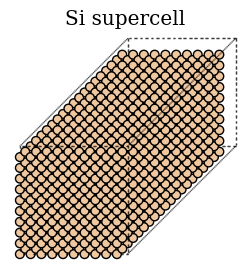



  Properties  Predictions (GPa)  DFT references (GPa)
         C11              139.0                   153
         C12               77.9                    57
         C44               48.6                    74
Bulk Modulus               98.3                    89


In [4]:
# Denote data path
data_folder = "kaldo_runs/"

# Extract supercell structure for later display
atoms = read(data_folder  + 'fd_NEP/replicated_atoms.xyz')

# Retrieve elastic constants and compute bulk modulus
# note that the equation works for cubic system only
Cijs = np.load(data_folder + 'Cij.npy')
C11 = Cijs[0, 0, 0, 0]
C12 = Cijs[0, 0, 1, 1]
C44 = Cijs[1, 2, 1, 2]
Bulk_modulus = (C11 + 2 * C12)/3

# Display supercell and bulk modulus side by side
figure(figsize=(4, 3))
set_fig_properties([gca()])
plot_atoms(atoms)
gca().axis('off')
gca().set_title('Si supercell')
show()

print('\n')

# Prepare data for pandas
df = pd.DataFrame({
    "Properties": ["C11", "C12", "C44", "Bulk Modulus"],
    "Predictions (GPa)": [C11, C12, C44, Bulk_modulus],
    "DFT references (GPa)": [153, 57, 74 ,89]
})

# Format the floats to one decimal place and print
pd.set_option('display.float_format', '{:.1f}'.format)
print(df.to_string(index=False))

### Plot Phonon Spectra (Dispersion) and Density of State (DOS)

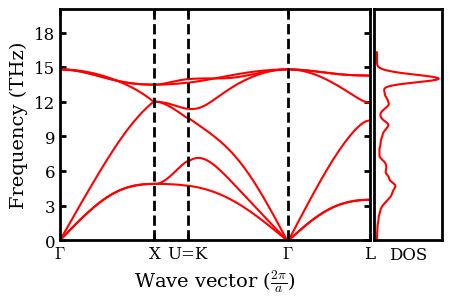

In [5]:
# Derive symbols for high symmetry directions in Brillouin zone
dispersion = np.loadtxt(data_folder  + 'plots/15_15_15/dispersion')
point_names = np.loadtxt(data_folder  + 'plots/15_15_15/point_names', dtype=str)

point_names_list = []
for point_name in point_names:
    if point_name == 'G':
        point_name = r'$\Gamma$'
    elif point_name == 'U':
        point_name = 'U=K'
    point_names_list.append(point_name)

# Load in the "tick-mark" values for these symbols
q = np.loadtxt(data_folder  + 'plots/15_15_15/q')
Q = np.loadtxt(data_folder  + 'plots/15_15_15/Q_val')

# Load in grid and dos individually
dos_Si= np.load(data_folder + 'plots/15_15_15/dos.npy')

# Plot dispersion
fig = figure(figsize=(4,3))
set_fig_properties([gca()])
plot(q[0], dispersion[0, 0], 'r-', ms=1)
plot(q, dispersion, 'r-', ms=1)
for i in range(1, 4):
    axvline(x=Q[i], ymin=0, ymax=2, ls='--',  lw=2, c="k")
ylabel('Frequency (THz)', fontsize=14)
xlabel(r'Wave vector ($\frac{2\pi}{a}$)', fontsize=14)
gca().set_yticks(np.arange(0, 24, 3))
xticks(Q, point_names_list)
ylim([0, 20])
xlim([Q[0], Q[4]])
dosax = fig.add_axes([0.91, .11, .17, .77])
set_fig_properties([gca()])

# Plot per projection
for d in np.expand_dims(dos_Si[1],0):
    dosax.plot(d, dos_Si[0],c='r')
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS")
ylim([0, 20])
show()

### Plot Heat Capacity, Group Velocities and Phase Space

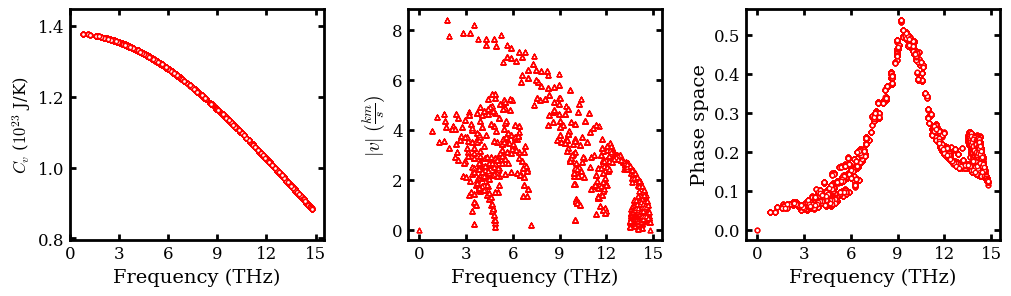

In [6]:
# Load in group velocity, heat_capacity (cv) and frequency data
frequency =  np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/frequency.npy',
    allow_pickle=True)

cv =  np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/300/quantum/heat_capacity.npy',
    allow_pickle=True)


group_velocity = np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/velocity.npy')

phase_space = np.load(data_folder +
 'ALD_Si_NEP/15_15_15/300/quantum/_ps_and_gamma.npy',
                      allow_pickle=True)[:,0]

# Compute norm of group velocity
# Convert the unit from angstrom / picosecond to kilometer/ second
group_velcotiy_norm = np.linalg.norm(
    group_velocity.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C')[3:], 1e23*cv.flatten(order='C')[3:], 
        facecolor='w', edgecolor='r', s=10, marker='8')
ylabel (r"$C_{v}$ ($10^{23}$ J/K)")
xlabel('Frequency (THz)', fontsize=14)
gca().set_xticks(np.arange(0, 18, 3))
ylim(0.9*1e23*cv.flatten(order='C')[3:].min(), 1.05*1e23*cv.flatten(order='C')[3:].max())

subplot(1 ,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        group_velcotiy_norm, facecolor='w', edgecolor='r', s=10, marker='^')
gca().set_xticks(np.arange(0, 18, 3))
xlabel('Frequency (THz)', fontsize=14)
ylabel(r'$|v| \ (\frac{km}{s})$', fontsize=14)

subplot(1 ,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        phase_space, facecolor='w', edgecolor='r', s=10, marker='o')
gca().set_xticks(np.arange(0, 18, 3))
xlabel('Frequency (THz)', fontsize=14)
ylabel('Phase space', fontsize=14)
subplots_adjust(wspace=0.33)
show()

### Plot Phonon Lifetime ($\tau$), Scattering Rate ($\Gamma$) $\&$ MFP ($\lambda$)
- Note that $\Gamma$ and $\tau$ are computed only with the relaxation time approximation (RTA).

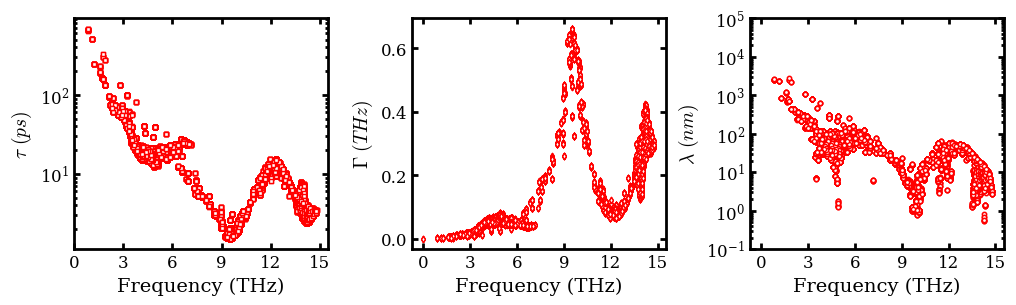

In [7]:
# Load in scattering rate
scattering_rate = np.load(
    data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/bandwidth.npy', allow_pickle=True)

# Derive lifetime, which is inverse of scattering rate
life_time = scattering_rate ** (-1)

# Denote lists to intake mean free path in each direction
mean_free_path = []
for i in range(3):
    mean_free_path.append(np.loadtxt(
    data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/inverse/mean_free_path_' +
    str(i) + '.dat'))

# Convert list to numpy array and compute norm for mean free path
# Convert the unit from angstrom  to nanometer
mean_free_path = np.array(mean_free_path).T
mean_free_path_norm = np.linalg.norm(
    mean_free_path.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        life_time, facecolor='w', edgecolor='r', s=10, marker='s')
gca().set_xticks(np.arange(0, 18, 3))
yscale('log')
ylabel(r'$\tau \ (ps)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        scattering_rate, facecolor='w', edgecolor='r', s=10, marker='d')
gca().set_xticks(np.arange(0, 18, 3))
ylabel(r'$\Gamma \ (THz)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        mean_free_path_norm, facecolor='w', edgecolor='r', s=10, marker='8')
gca().set_xticks(np.arange(0, 18, 3))
ylabel(r'$\lambda \ (nm)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
yscale('log')
ylim([1e-1, 1e5])
subplots_adjust(wspace=0.33)
show()

### Plot per mode and cumulative $\kappa$

Bulk thermal conductivity: 124.7 W m^-1 K^-1

kappa matrix: 
[[124.47729705   0.21930178   0.23628815]
 [  0.2148875  125.14822832   0.21680457]
 [  0.23629108   0.2211428  124.48390703]]


Bulk thermal conductivity with isotopic scattering: 115.4 W m^-1 K^-1

kappa matrix with isotopic scattering: 
[[115.14486076   0.18775026   0.20513438]
 [  0.18378888 115.78862887   0.18565699]
 [  0.20514524   0.18954223 115.15121167]]




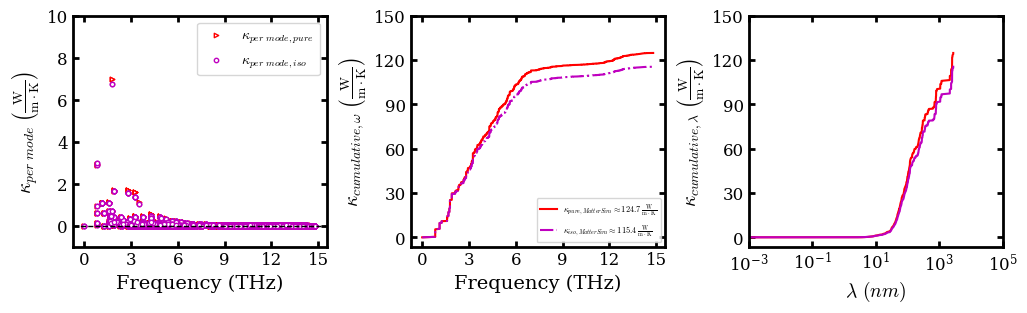

In [8]:
# Denote zeros to intake kappa tensor
kappa_tensor = np.zeros([mean_free_path.shape[0], 3, 3])
kappa_tensor_iso = np.zeros([mean_free_path.shape[0], 3, 3])

for i in range(3):
    for j in range(3):
        kappa_tensor[:, i, j] = np.loadtxt(data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/inverse/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
        kappa_tensor_iso[:, i, j] = np.loadtxt(data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/isotopes/inverse/conductivity_' +
    str(i) + '_' + str(j) + '.dat')

# Sum over the 0th dimension to recover 3-by-3 kappa matrix
kappa_matrix = kappa_tensor.sum(axis=0)
print("Bulk thermal conductivity: %.1f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix)))
print("kappa matrix: ")
print(kappa_matrix)
print('\n')

kappa_matrix_iso = kappa_tensor_iso.sum(axis=0)
print("Bulk thermal conductivity with isotopic scattering: %.1f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_iso)))
print("kappa matrix with isotopic scattering: ")
print(kappa_matrix_iso)
print('\n')

# Compute kappa in per mode and cumulative representations
kappa_per_mode = kappa_tensor.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor)
lambda_sorted, kappa_cum_wrt_lambda = cumulative_cond_cal(
    mean_free_path_norm, kappa_tensor)

kappa_per_mode_iso = kappa_tensor_iso.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq_iso = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor_iso)
lambda_sorted, kappa_cum_wrt_lambda_iso = cumulative_cond_cal(
    mean_free_path_norm, kappa_tensor_iso)

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        kappa_per_mode, facecolor='w', edgecolor='r', s=10, marker='>', label='$\kappa_{per \ mode, pure }$')
scatter(frequency.flatten(order='C'),
        kappa_per_mode_iso, facecolor='w', edgecolor='m', s=10, marker='o', label='$\kappa_{per \ mode, iso }$')
gca().set_xticks(np.arange(0, 18, 3))
gca().axhline(y = 0, color='k', ls='--', lw=1)
ylabel(r'$\kappa_{per \ mode}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=1, fontsize=10)
ylim([-1, 10])

subplot(1,3, 2)
set_fig_properties([gca()])
plot(freq_sorted, kappa_cum_wrt_freq, 'r',
     label=r'$\kappa_{pure, MatterSim} \approx 124.7\;\frac{\rm{W}}{\rm{m}\cdot\rm{K}}$')
plot(freq_sorted, kappa_cum_wrt_freq_iso, c='m', 
     ls='-.', label=r"$\kappa_{iso,MatterSim} \approx 115.4\;\frac{\rm{W}}{\rm{m}\cdot\rm{K}}$")
gca().set_xticks(np.arange(0, 18, 3))
gca().set_yticks(np.arange(0, 180, 30))
ylabel(r'$\kappa_{cumulative, \omega}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=4, fontsize=6)

subplot(1,3, 3)
set_fig_properties([gca()])
plot(lambda_sorted, kappa_cum_wrt_lambda, 'r')
plot(lambda_sorted, kappa_cum_wrt_lambda_iso, c='m')
gca().set_xticks(np.arange(0, 18, 3))
gca().set_yticks(np.arange(0, 180, 30))
xlabel(r'$\lambda \ (nm)$', fontsize=14)
ylabel(r'$\kappa_{cumulative, \lambda}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xscale('log')
xlim([1e-3, 1e5])
subplots_adjust(wspace=0.33)
show()

---

### Anharmonic Lattice Dynamics (ALD) for $\ce{Si}$ with [NEP89](https://arxiv.org/abs/2504.21286)

#### Import Necessary Packages

In [1]:
from ase.io import read
from ase.visualize.plot import plot_atoms
import pandas as pd
from pylab import *
import warnings
warnings.filterwarnings("ignore")

#### Custom Define Functions

In [2]:
def cumulative_cond_cal(observables, kappa_tensor, prefactor=1/3):

    """Compute cumulative conductivity based on either frequency or mean-free path

       input:
       observables: (ndarray) either phonon frequency or mean-free path
       cond_tensor: (ndarray) conductivity tensor
       prefactor: (float) prefactor to average kappa tensor, 1/3 for bulk material

       ouput:
       observeables: (ndarray) sorted phonon frequency or mean-free path
       kappa_cond (ndarray) cumulative conductivity

    """

    # Sum over kappa by directions
    kappa = np.einsum('maa->m', prefactor * kappa_tensor)

    # Sort observables
    observables_argsort_indices = np.argsort(observables)
    cumulative_kappa = np.cumsum(kappa[observables_argsort_indices])
    return observables[observables_argsort_indices], cumulative_kappa



def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

#### Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

#### Illustrate Crystal Structure and Elastic Constants
- DFT reference for the elastic modulus is adopted from: https://next-gen.materialsproject.org/materials/mp-149

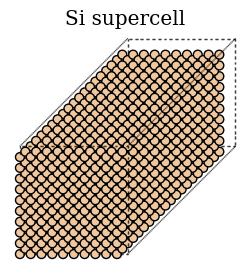



  Properties  Predictions (GPa)  DFT references (GPa)
         C11              128.9                   153
         C12               95.3                    57
         C44               27.1                    74
Bulk Modulus              106.5                    89


In [4]:
# Denote data path
data_folder = "kaldo_runs/"

# Extract supercell structure for later display
atoms = read(data_folder  + 'fd_NEP/replicated_atoms.xyz')

# Retrieve elastic constants and compute bulk modulus
# note that the equation works for cubic system only
Cijs = np.load(data_folder + 'Cij.npy')
C11 = Cijs[0, 0, 0, 0]
C12 = Cijs[0, 0, 1, 1]
C44 = Cijs[1, 2, 1, 2]
Bulk_modulus = (C11 + 2 * C12)/3

# Display supercell and bulk modulus side by side
figure(figsize=(4, 3))
set_fig_properties([gca()])
plot_atoms(atoms)
gca().axis('off')
gca().set_title('Si supercell')
show()

print('\n')

# Prepare data for pandas
df = pd.DataFrame({
    "Properties": ["C11", "C12", "C44", "Bulk Modulus"],
    "Predictions (GPa)": [C11, C12, C44, Bulk_modulus],
    "DFT references (GPa)": [153, 57, 74 ,89]
})

# Format the floats to one decimal place and print
pd.set_option('display.float_format', '{:.1f}'.format)
print(df.to_string(index=False))

#### Plot Phonon Spectra (Dispersion) and Density of State (DOS)

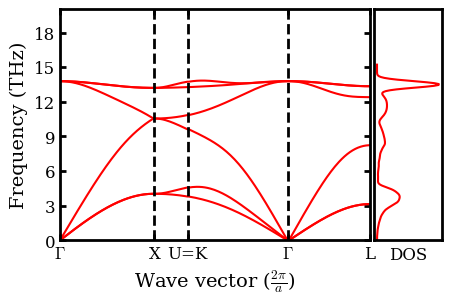

In [5]:
# Derive symbols for high symmetry directions in Brillouin zone
dispersion = np.loadtxt(data_folder  + 'plots/15_15_15/dispersion')
point_names = np.loadtxt(data_folder  + 'plots/15_15_15/point_names', dtype=str)

point_names_list = []
for point_name in point_names:
    if point_name == 'G':
        point_name = r'$\Gamma$'
    elif point_name == 'U':
        point_name = 'U=K'
    point_names_list.append(point_name)

# Load in the "tick-mark" values for these symbols
q = np.loadtxt(data_folder  + 'plots/15_15_15/q')
Q = np.loadtxt(data_folder  + 'plots/15_15_15/Q_val')

# Load in grid and dos individually
dos_Si= np.load(data_folder + 'plots/15_15_15/dos.npy')

# Plot dispersion
fig = figure(figsize=(4,3))
set_fig_properties([gca()])
plot(q[0], dispersion[0, 0], 'r-', ms=1)
plot(q, dispersion, 'r-', ms=1)
for i in range(1, 4):
    axvline(x=Q[i], ymin=0, ymax=2, ls='--',  lw=2, c="k")
ylabel('Frequency (THz)', fontsize=14)
xlabel(r'Wave vector ($\frac{2\pi}{a}$)', fontsize=14)
gca().set_yticks(np.arange(0, 24, 3))
xticks(Q, point_names_list)
ylim([0, 20])
xlim([Q[0], Q[4]])
dosax = fig.add_axes([0.91, .11, .17, .77])
set_fig_properties([gca()])

# Plot per projection
for d in np.expand_dims(dos_Si[1],0):
    dosax.plot(d, dos_Si[0],c='r')
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS")
ylim([0, 20])
show()

#### Plot Heat Capacity, Group Velocities and Phase Space

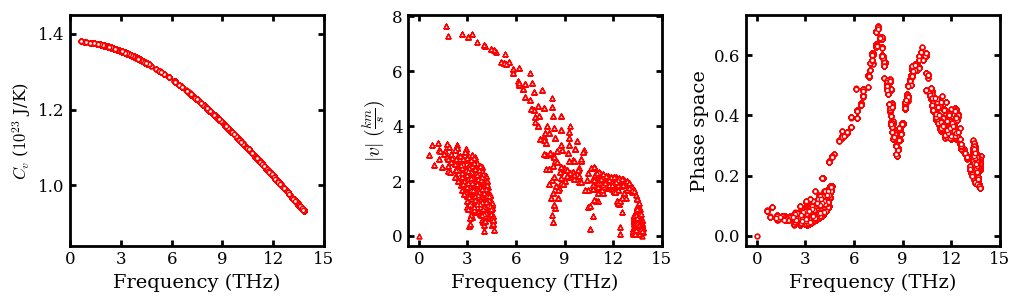

In [6]:
# Load in group velocity, heat_capacity (cv) and frequency data
frequency =  np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/frequency.npy',
    allow_pickle=True)

cv =  np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/300/quantum/heat_capacity.npy',
    allow_pickle=True)


group_velocity = np.load(
    data_folder + 'ALD_Si_NEP/15_15_15/velocity.npy')

phase_space = np.load(data_folder +
 'ALD_Si_NEP/15_15_15/300/quantum/_ps_and_gamma.npy',
                      allow_pickle=True)[:,0]

# Compute norm of group velocity
# Convert the unit from angstrom / picosecond to kilometer/ second
group_velcotiy_norm = np.linalg.norm(
    group_velocity.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C')[3:], 1e23*cv.flatten(order='C')[3:], 
        facecolor='w', edgecolor='r', s=10, marker='8')
ylabel (r"$C_{v}$ ($10^{23}$ J/K)")
xlabel('Frequency (THz)', fontsize=14)
gca().set_xticks(np.arange(0, 18,3))
ylim(0.9*1e23*cv.flatten(order='C')[3:].min(), 1.05*1e23*cv.flatten(order='C')[3:].max())

subplot(1 ,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        group_velcotiy_norm, facecolor='w', edgecolor='r', s=10, marker='^')
xlabel('Frequency (THz)', fontsize=14)
ylabel(r'$|v| \ (\frac{km}{s})$', fontsize=14)
gca().set_xticks(np.arange(0, 18,3))

subplot(1 ,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        phase_space, facecolor='w', edgecolor='r', s=10, marker='o')
gca().set_xticks(np.arange(0, 18,3))
xlabel('Frequency (THz)', fontsize=14)
ylabel('Phase space', fontsize=14)
subplots_adjust(wspace=0.33)
show()

#### Plot Phonon Lifetime ($\tau$), Scattering Rate ($\Gamma$) $\&$ MFP ($\lambda$)
- Note that $\Gamma$ and $\tau$ are computed only with the relaxation time approximation (RTA).

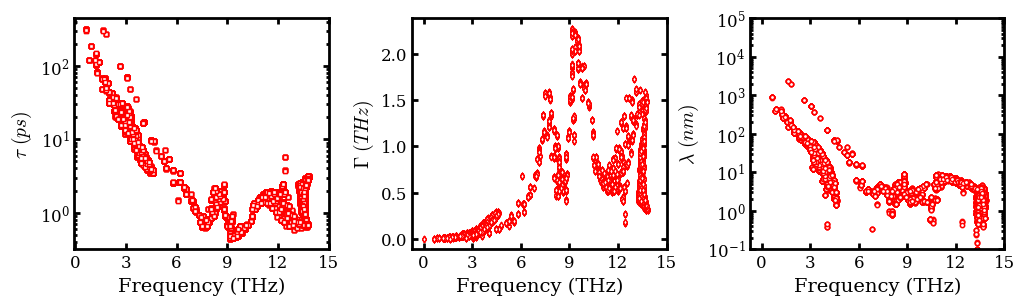

In [7]:
# Load in scattering rate
scattering_rate = np.load(
    data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/bandwidth.npy', allow_pickle=True)

# Derive lifetime, which is inverse of scattering rate
life_time = scattering_rate ** (-1)

# Denote lists to intake mean free path in each direction
mean_free_path = []
for i in range(3):
    mean_free_path.append(np.loadtxt(
    data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/inverse/mean_free_path_' +
    str(i) + '.dat'))

# Convert list to numpy array and compute norm for mean free path
# Convert the unit from angstrom  to nanometer
mean_free_path = np.array(mean_free_path).T
mean_free_path_norm = np.linalg.norm(
    mean_free_path.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        life_time, facecolor='w', edgecolor='r', s=10, marker='s')
gca().set_xticks(np.arange(0, 18,3))
yscale('log')
ylabel(r'$\tau \ (ps)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        scattering_rate, facecolor='w', edgecolor='r', s=10, marker='d')
gca().set_xticks(np.arange(0, 18,3))
ylabel(r'$\Gamma \ (THz)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        mean_free_path_norm, facecolor='w', edgecolor='r', s=10, marker='8')
gca().set_xticks(np.arange(0, 18,3))
ylabel(r'$\lambda \ (nm)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
yscale('log')
ylim([1e-1, 1e5])
subplots_adjust(wspace=0.33)
show()

#### Plot per mode and cumulative $\kappa$

Bulk thermal conductivity: 41.9 W m^-1 K^-1

kappa matrix: 
[[4.18749844e+01 1.63619465e-02 1.75311544e-02]
 [1.68626905e-02 4.20726758e+01 1.74282781e-02]
 [1.73739345e-02 1.68744158e-02 4.18815074e+01]]


Bulk thermal conductivity with isotopic scattering: 39.8 W m^-1 K^-1

kappa matrix with isotopic scattering: 
[[ 3.97230940e+01 -1.92639509e-02 -1.79641626e-02]
 [-1.86990822e-02  3.99191637e+01 -1.82495936e-02]
 [-1.81077650e-02 -1.88714157e-02  3.97295398e+01]]




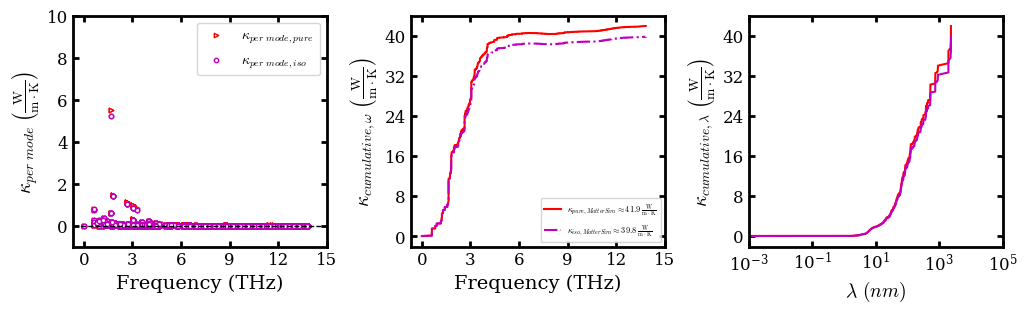

In [8]:
# Denote zeros to intake kappa tensor
kappa_tensor = np.zeros([mean_free_path.shape[0], 3, 3])
kappa_tensor_iso = np.zeros([mean_free_path.shape[0], 3, 3])

for i in range(3):
    for j in range(3):
        kappa_tensor[:, i, j] = np.loadtxt(data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/inverse/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
        kappa_tensor_iso[:, i, j] = np.loadtxt(data_folder +
    'ALD_Si_NEP/15_15_15/300/quantum/isotopes/inverse/conductivity_' +
    str(i) + '_' + str(j) + '.dat')

# Sum over the 0th dimension to recover 3-by-3 kappa matrix
kappa_matrix = kappa_tensor.sum(axis=0)
print("Bulk thermal conductivity: %.1f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix)))
print("kappa matrix: ")
print(kappa_matrix)
print('\n')

kappa_matrix_iso = kappa_tensor_iso.sum(axis=0)
print("Bulk thermal conductivity with isotopic scattering: %.1f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_iso)))
print("kappa matrix with isotopic scattering: ")
print(kappa_matrix_iso)
print('\n')

# Compute kappa in per mode and cumulative representations
kappa_per_mode = kappa_tensor.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor)
lambda_sorted, kappa_cum_wrt_lambda = cumulative_cond_cal(
    mean_free_path_norm, kappa_tensor)

kappa_per_mode_iso = kappa_tensor_iso.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq_iso = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor_iso)
lambda_sorted, kappa_cum_wrt_lambda_iso = cumulative_cond_cal(
    mean_free_path_norm, kappa_tensor_iso)

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        kappa_per_mode, facecolor='w', edgecolor='r', s=10, marker='>', label='$\kappa_{per \ mode, pure }$')
scatter(frequency.flatten(order='C'),
        kappa_per_mode_iso, facecolor='w', edgecolor='m', s=10, marker='o', label='$\kappa_{per \ mode, iso }$')
gca().set_xticks(np.arange(0, 18,3))
gca().axhline(y = 0, color='k', ls='--', lw=1)
ylabel(r'$\kappa_{per \ mode}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=1, fontsize=10)
ylim([-1, 10])

subplot(1,3, 2)
set_fig_properties([gca()])
plot(freq_sorted, kappa_cum_wrt_freq, 'r',
     label=r'$\kappa_{pure, MatterSim} \approx 41.9\;\frac{\rm{W}}{\rm{m}\cdot\rm{K}}$')
plot(freq_sorted, kappa_cum_wrt_freq_iso, c='m', 
     ls='-.', label=r"$\kappa_{iso,MatterSim} \approx 39.8\;\frac{\rm{W}}{\rm{m}\cdot\rm{K}}$")
gca().set_xticks(np.arange(0, 18,3))
gca().set_yticks(np.arange(0, 48, 8))
ylabel(r'$\kappa_{cumulative, \omega}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=4, fontsize=6)

subplot(1,3, 3)
set_fig_properties([gca()])
plot(lambda_sorted, kappa_cum_wrt_lambda, 'r')
plot(lambda_sorted, kappa_cum_wrt_lambda_iso, c='m')
gca().set_xticks(np.arange(0, 18,3))
gca().set_yticks(np.arange(0, 48, 8))
xlabel(r'$\lambda \ (nm)$', fontsize=14)
ylabel(r'$\kappa_{cumulative, \lambda}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xscale('log')
xlim([1e-3, 1e5])
subplots_adjust(wspace=0.33)
show()